In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import shap
import sys

from xgboost import XGBRegressor, plot_importance
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

from scipy.stats import randint, uniform, loguniform

In [12]:
inf_data = pd.read_csv('..//data//processed//combined_macro_data.csv').set_index(['Date'])
inf_data.index = pd.to_datetime(inf_data.index)
inf_rate = inf_data['InflationRate'].dropna()

In [13]:
def create_date_features(data):
    
    date_columns = [data, ]
    date_columns.append(pd.Series(np.sin(2*np.pi*data.index.month/12), name = 'Month_Sin', index = data.index))
    date_columns.append(pd.Series(np.cos(2*np.pi*data.index.month/12), name = 'Month_Cos', index = data.index))

    return pd.concat(date_columns, axis = 1)

def create_lag_features(data, lag_list, lag_column = None):

    if lag_column is None:
        column = data
        lag_column = data.name
    else:
        column = data[lag_column]

    lag_columns = [data,]
    for lag in lag_list:
        lag_columns.append(pd.Series(column.shift(lag), name = '{}_Lag{}'.format(lag_column, lag)))
    
    return pd.concat(lag_columns, axis = 1)

def create_rolling_features(data, window_list, rolling_column = None):

    if rolling_column is None:
        column = data
        rolling_column = data.name
    else:
        column = data[rolling_column]

    
    rolling_columns = [data,]
    for window in window_list:
        rolling_columns.append(pd.Series(column.shift(1).rolling(window).mean(), name = '{}_RollMean{}'.format(rolling_column, window))) #lagged to avoid leakage
        rolling_columns.append(pd.Series(column.shift(1).rolling(window).std(), name = '{}_RollSTD{}'.format(rolling_column, window)))
    
    return pd.concat(rolling_columns, axis = 1)

def nexog_feature_split(data, lag_list = [1, 2, 13, 24], window_list = [3, 6, 12]):
    date = create_date_features(data = data.dropna())
    lag = create_lag_features(data=date, lag_list = lag_list, lag_column = data.name)
    final = create_rolling_features(data = lag, rolling_column = data.name, window_list = window_list)
    forecast_feat = final[[col for col in final.columns if col != data.name]].iloc[[-1]]

    return final, forecast_feat


In [14]:
final_inf, forecast_feat = nexog_feature_split(inf_rate) 
final_inf.tail()

,InflationRate,Month_Sin,Month_Cos,InflationRate_Lag1,InflationRate_Lag2,InflationRate_Lag13,InflationRate_Lag24,InflationRate_RollMean3,InflationRate_RollSTD3,InflationRate_RollMean6,InflationRate_RollSTD6,InflationRate_RollMean12,InflationRate_RollSTD12
Date,,,,,,,,,,,,,
2026-01-01,2.024922,0.500000,8.660254e-01,1.801096,1.496063,2.900886,2.800659,1.652413,0.152661,1.524755,0.308271,1.659842,0.482085
2026-02-01,2.419984,0.866025,5.000000e-01,2.024922,1.801096,2.884615,3.377265,1.774027,0.265467,1.704139,0.200157,1.588201,0.320240
2026-03-01,4.068858,1.000000,6.123234e-17,2.419984,2.024922,2.071713,3.715937,2.082001,0.313367,1.857338,0.325754,1.617223,0.378521
2026-04-01,7.227023,0.866025,-5.000000e-01,4.068858,2.419984,1.751592,3.804797,2.837921,1.084169,2.245167,0.949273,1.810329,0.804591
2026-05-01,6.761006,0.500000,-8.660254e-01,7.227023,4.068858,1.434263,3.887510,4.571955,2.442690,3.172991,2.182522,2.293059,1.745744


In [15]:
def best_params(n_iter):
    param_grid = {
    "n_estimators": randint(200, 2500),
    "learning_rate": loguniform(0.005, 0.2),
    "max_depth": randint(2, 10),
    "min_child_weight": randint(1, 15),
    "subsample": uniform(0.5, 0.5),          # 0.5 - 1.0
    "colsample_bytree": uniform(0.5, 0.5),
    "gamma": uniform(0, 5),
    "reg_alpha": loguniform(1e-5, 10),
    "reg_lambda": loguniform(1e-2, 100)
    }

    tscv = TimeSeriesSplit(n_splits=5, test_size = 24)
    base_model = XGBRegressor(objective="reg:squarederror", random_state=420)
    search = RandomizedSearchCV(base_model, param_distributions=param_grid, n_iter = n_iter, scoring="neg_root_mean_squared_error", cv=tscv, random_state=420, n_jobs=-1)
    
    return search

def train_test_split(data, n_months, targ_col, feat_cols):
    
    if type(targ_col) == str:
        targ_col = targ_col

    else:
        targ_col = targ_col[0]
    
    train = data[:-n_months]
    test = data[-n_months:]

    train_targ = train[targ_col]
    train_feat = train[feat_cols]
    test_targ = test[targ_col]
    test_feat = test[feat_cols]


    return train_feat, train_targ, test_feat, test_targ

In [16]:
def model_pred(train_feat, train_targ, pred_feat, n_iter):
    model_test = best_params(n_iter)
    model_test.fit(train_feat, train_targ)
    pred_targ = model_test.best_estimator_.predict(pred_feat)
    return pred_targ, model_test

def test_diag(data, targ_col, n_iter):
    feat_cols = [col for col in data.columns if col != targ_col]
    train_feat, train_targ, test_feat, test_targ = train_test_split(data.dropna(), 24, targ_col=targ_col, feat_cols=feat_cols)
    pred_targ, model_test = model_pred(train_feat=train_feat, train_targ=train_targ, pred_feat=test_feat, n_iter=n_iter)
    rmse = np.sqrt(mean_squared_error(test_targ, pred_targ))
    std = np.std(test_targ)
    r2 = r2_score(test_targ, pred_targ)
    cv_rmse = -model_test.best_score_
    print(f"CV RMSE   : {cv_rmse:.3f}")
    print(f"Test RMSE : {rmse:.3f}")
    print(f"Test STD  : {std:.3f}")
    print(f"R²        : {r2:.3f}")
    print(f"Best Params:\n{model_test.best_params_}")
    return {"cv_rmse": cv_rmse, "test_rmse": rmse, "test_std": std, "r2": r2, "best_params": model_test.best_params_}

In [17]:
test_results = test_diag(final_inf, 'InflationRate', n_iter = 100)

KeyboardInterrupt: 

In [ ]:
def forecast_df(data, targ_col):

    feat_cols = [col for col in data.columns if col != targ_col]

    forecast_feat = data[feat_cols].iloc[[-1]].copy()

    forecast_feat.index = forecast_feat.index + pd.offsets.MonthBegin(1)

    full_feat = data[feat_cols].copy()
    full_feat.index = full_feat.index + pd.offsets.MonthBegin(1)

    full_targ = data[targ_col]

    full_df = pd.concat([full_targ, full_feat], axis=1).dropna()

    return full_df[feat_cols], full_df[targ_col], forecast_feat

In [ ]:
def months_ahead_forecast(data, months_ahead):
    
    iter = 1

    final_data, _ = nexog_feature_split(data)
    full_feat, full_targ, forecast_feat = forecast_df(final_data, data.name)
    _, model_test = model_pred(full_feat, full_targ, forecast_feat, n_iter=100)
    model = model_test.best_estimator_
    last_obs = forecast_feat.iloc[[0]]

    while iter <= months_ahead:
        final_data, _ = nexog_feature_split(data)
        _, _, forecast_feat = forecast_df(final_data, data.name)
        model_forecast = model.predict(forecast_feat)
        one_step = pd.Series(model_forecast, index=forecast_feat.index, name=data.name)
        data = pd.concat([data, one_step])

        iter += 1

    explainer = shap.TreeExplainer(model)

    shap.waterfall_plot(shap.Explanation(values=explainer.shap_values(last_obs)[0], base_values=explainer.expected_value, data=last_obs.iloc[0], feature_names=last_obs.columns))
    plt.show()
    
    return data

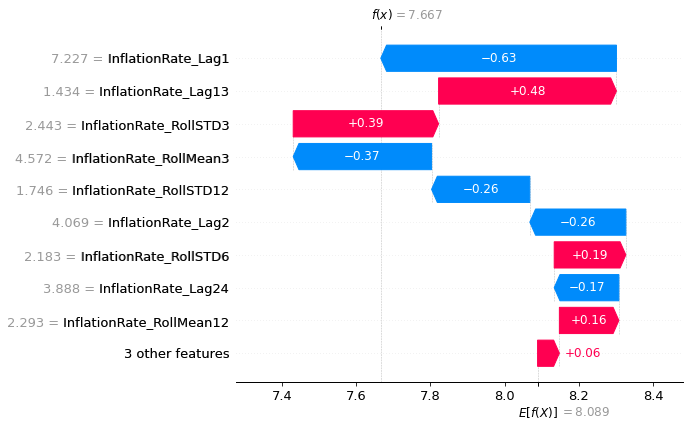

In [ ]:
months_ahead = 6
forecast = months_ahead_forecast(inf_rate, months_ahead = months_ahead)